In [2]:
library(Seurat)
library(ggplot2)
library(dplyr)
library(tidyr)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following object is masked from ‘package:base’:

    intersect



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




<h3 id="WT-3">WT 1</h3>

In [3]:
# 1. Read the QuPath exported CSV
qupath_data <- read.csv('/share/crsp/lab/dalawson/share/5_mouse_CODEX/measurements_csv_for_Tatyana/measurements_WT_1.csv', check.names = FALSE)

# 2. Extract spatial coordinates (using dots instead of spaces)
spatial_coords <- qupath_data %>% 
  select(`Centroid X µm`, `Centroid Y µm`)
rownames(spatial_coords) <- paste0("cell_", seq_len(nrow(spatial_coords)))

# 3. Extract only the Nuclear intensity columns for the matrix
# (Excluding metadata columns like Image, Class, Centroid X, etc.)
intensity_matrix <- qupath_data %>%
  select(contains("Nucleus: Mean")) %>%
  t() # Transpose so markers are rows and cells are columns

# Clean up marker names (e.g., "DAPI Nucleus: Mean" -> "DAPI")
rownames(intensity_matrix) <- gsub(" Nucleus: Mean", "", rownames(intensity_matrix))
colnames(intensity_matrix) <- rownames(spatial_coords)

# 4. Create the Seurat Object
seurat_obj <- CreateSeuratObject(counts = intensity_matrix, assay = "Multiplex")

# 5. Add the spatial coordinates as centroids
centroids <- CreateCentroids(spatial_coords)
coords <- CreateFOV(centroids, assay = "Multiplex", key = "fov_")
seurat_obj[["fov"]] <- coords

Warning message:
“Data is of class matrix. Coercing to dgCMatrix.”


In [5]:
# 1. Create a vector of the genes you want to keep
variable_genes <- c("DAPI-01:", "Keratin5:", "SMA:", 
                  "Keratin5:", "Keratin14:", "Keratin8:")

In [7]:
codex.obj <- seurat_obj

In [11]:
codex.obj <- NormalizeData(object = codex.obj, normalization.method = "CLR", margin = 2)
codex.obj <- ScaleData(codex.obj)
VariableFeatures(codex.obj) <- variable_genes  # since the panel is small, treat these features as variable.
codex.obj <- RunPCA(object = codex.obj, npcs = 4, verbose = FALSE)
codex.obj <- FindNeighbors(object = codex.obj, dims = 1:4, verbose = FALSE)
codex.obj <- FindClusters(object = codex.obj, verbose = FALSE, resolution = 0.5, n.start = 1)

Normalizing layer: counts

Normalizing across cells

Centering and scaling data matrix

Warning message in irlba(A = t(x = object), nv = npcs, ...):
“You're computing too large a percentage of total singular values, use a standard svd instead.”


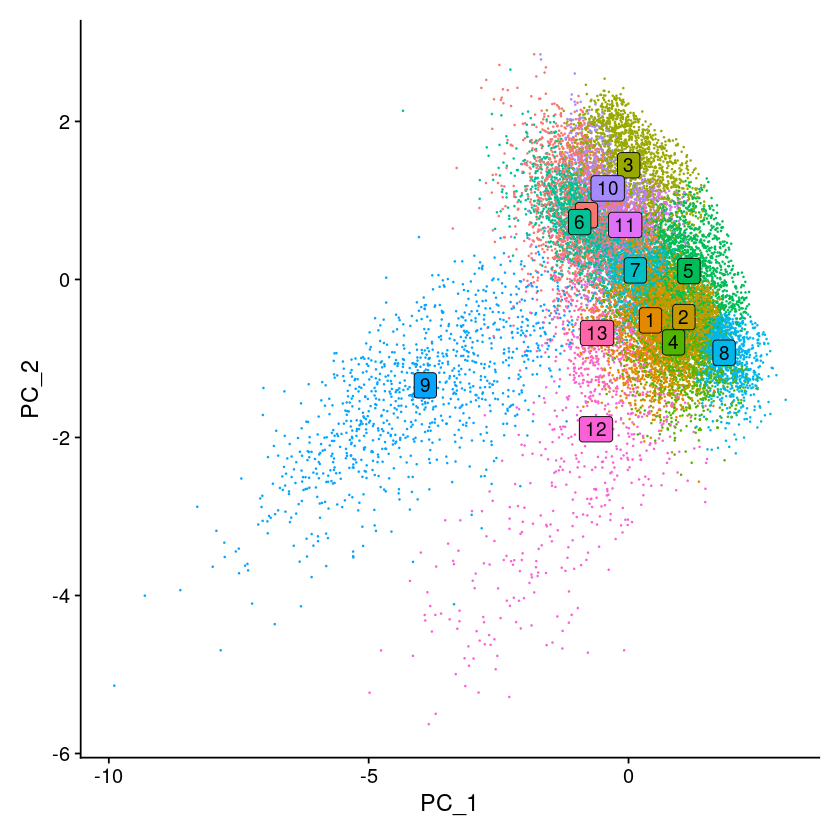

In [12]:
options(repr.plot.height = 7,
        repr.plot.width = 7)
DimPlot(codex.obj, label = TRUE, label.box = TRUE) + NoLegend()

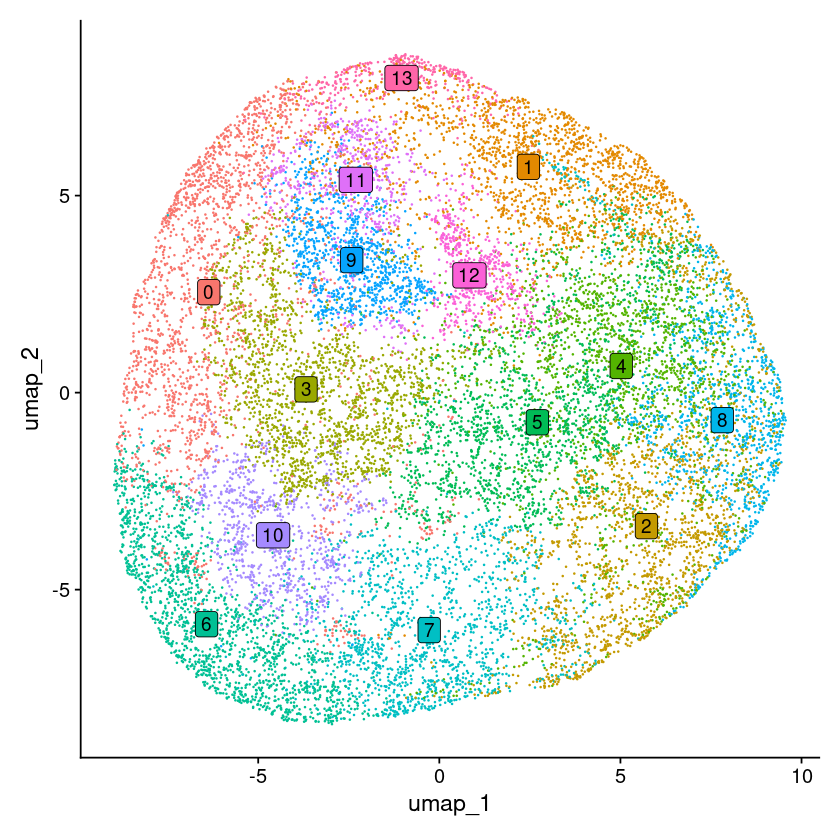

In [14]:
options(repr.plot.height = 7,
        repr.plot.width = 7)

codex.obj <- RunUMAP(object = codex.obj, dims = 1:4, verbose = FALSE)
DimPlot(codex.obj, label = TRUE, label.box = TRUE) + NoLegend()

In [15]:
genes <- variable_genes

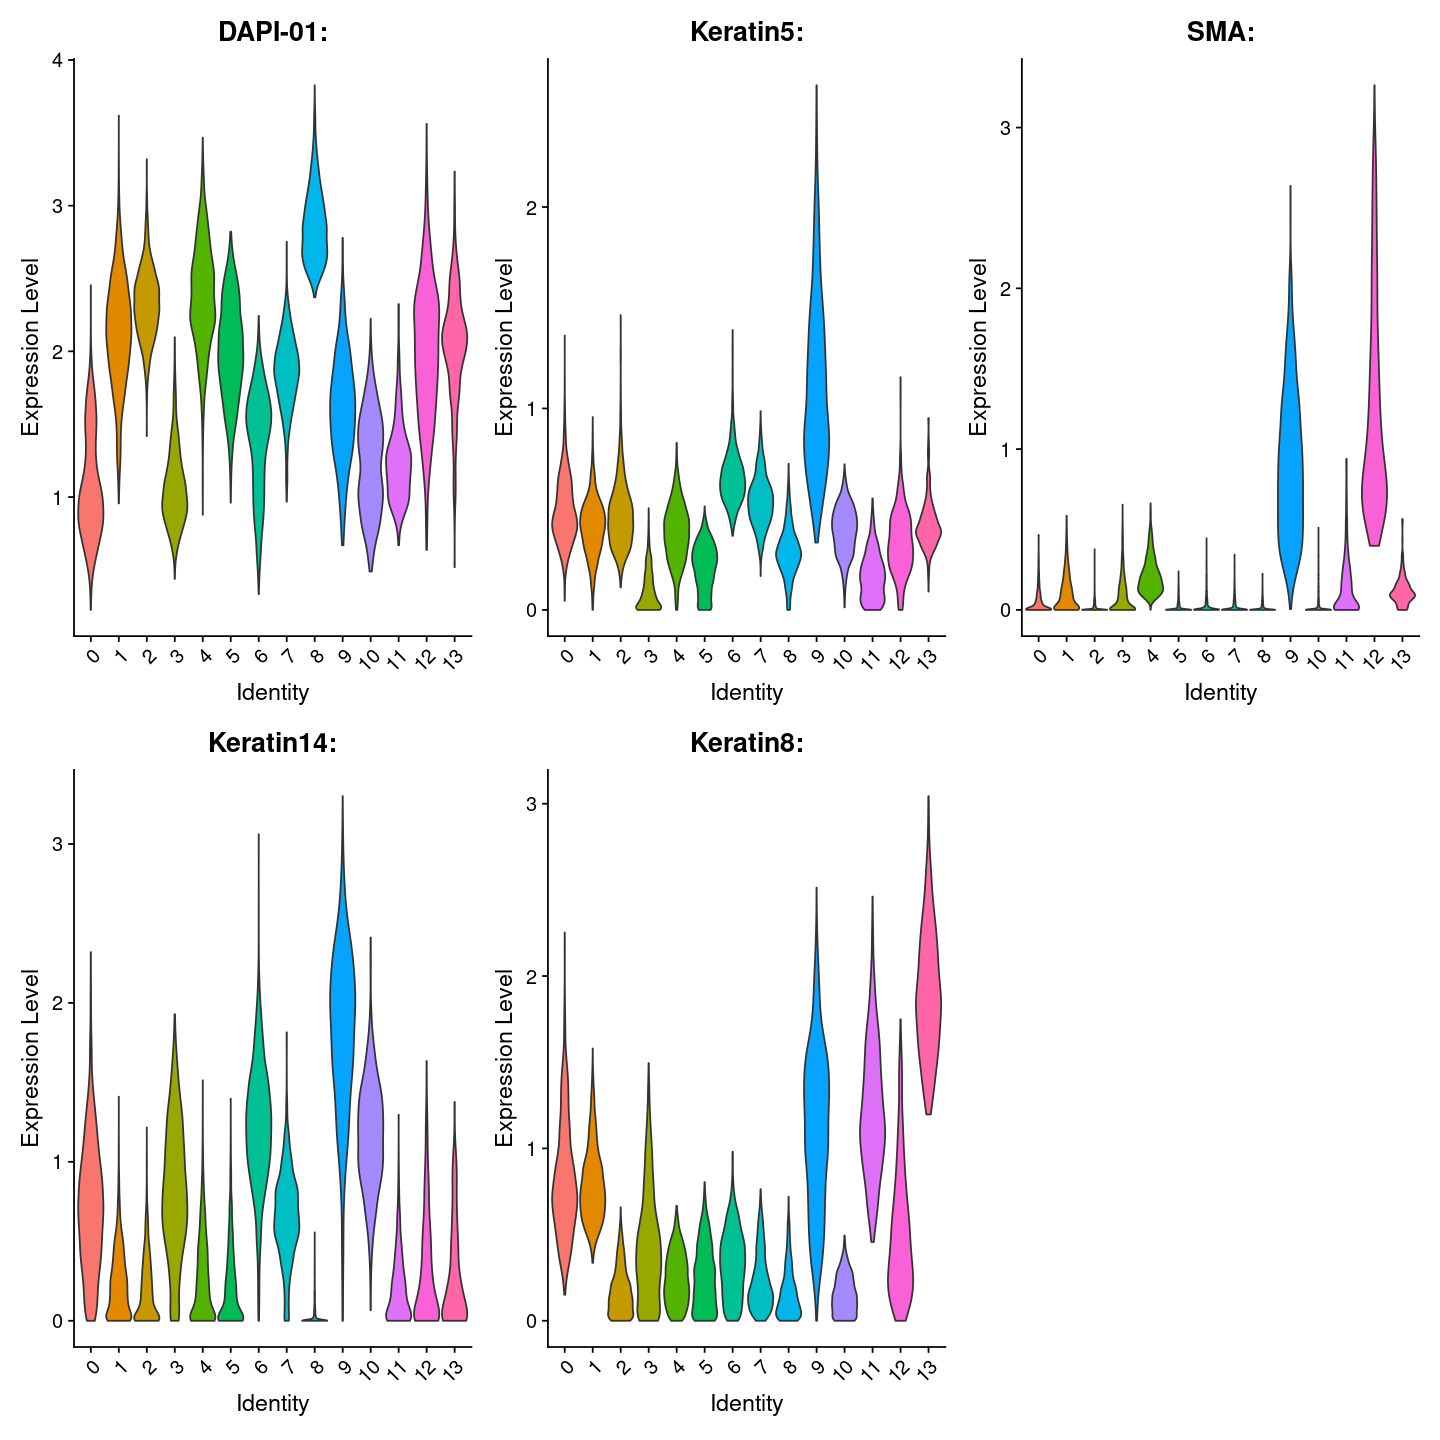

In [16]:
options(repr.plot.height = 12,
        repr.plot.width = 12)

VlnPlot(codex.obj, features = genes, pt.size=0)

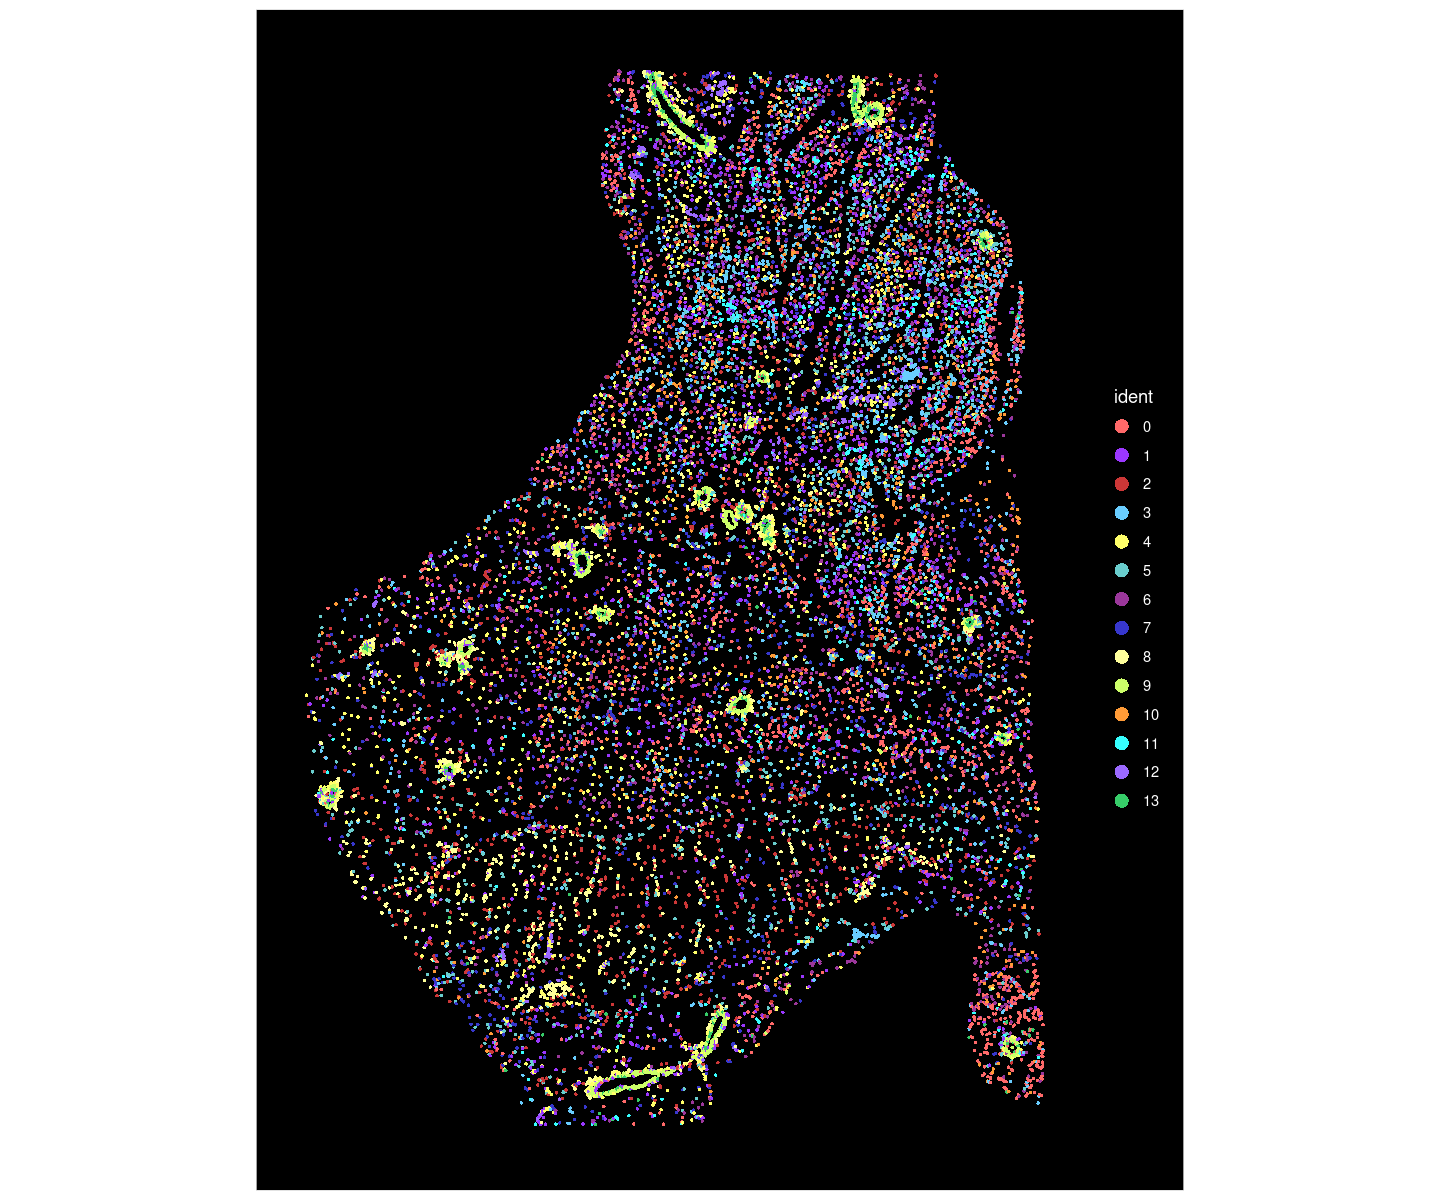

In [17]:
options(repr.plot.height = 10,
        repr.plot.width = 12)

Idents(codex.obj) <- "seurat_clusters"

ImageDimPlot(codex.obj, cols = "parade", size = 1)

Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Seurat objects”


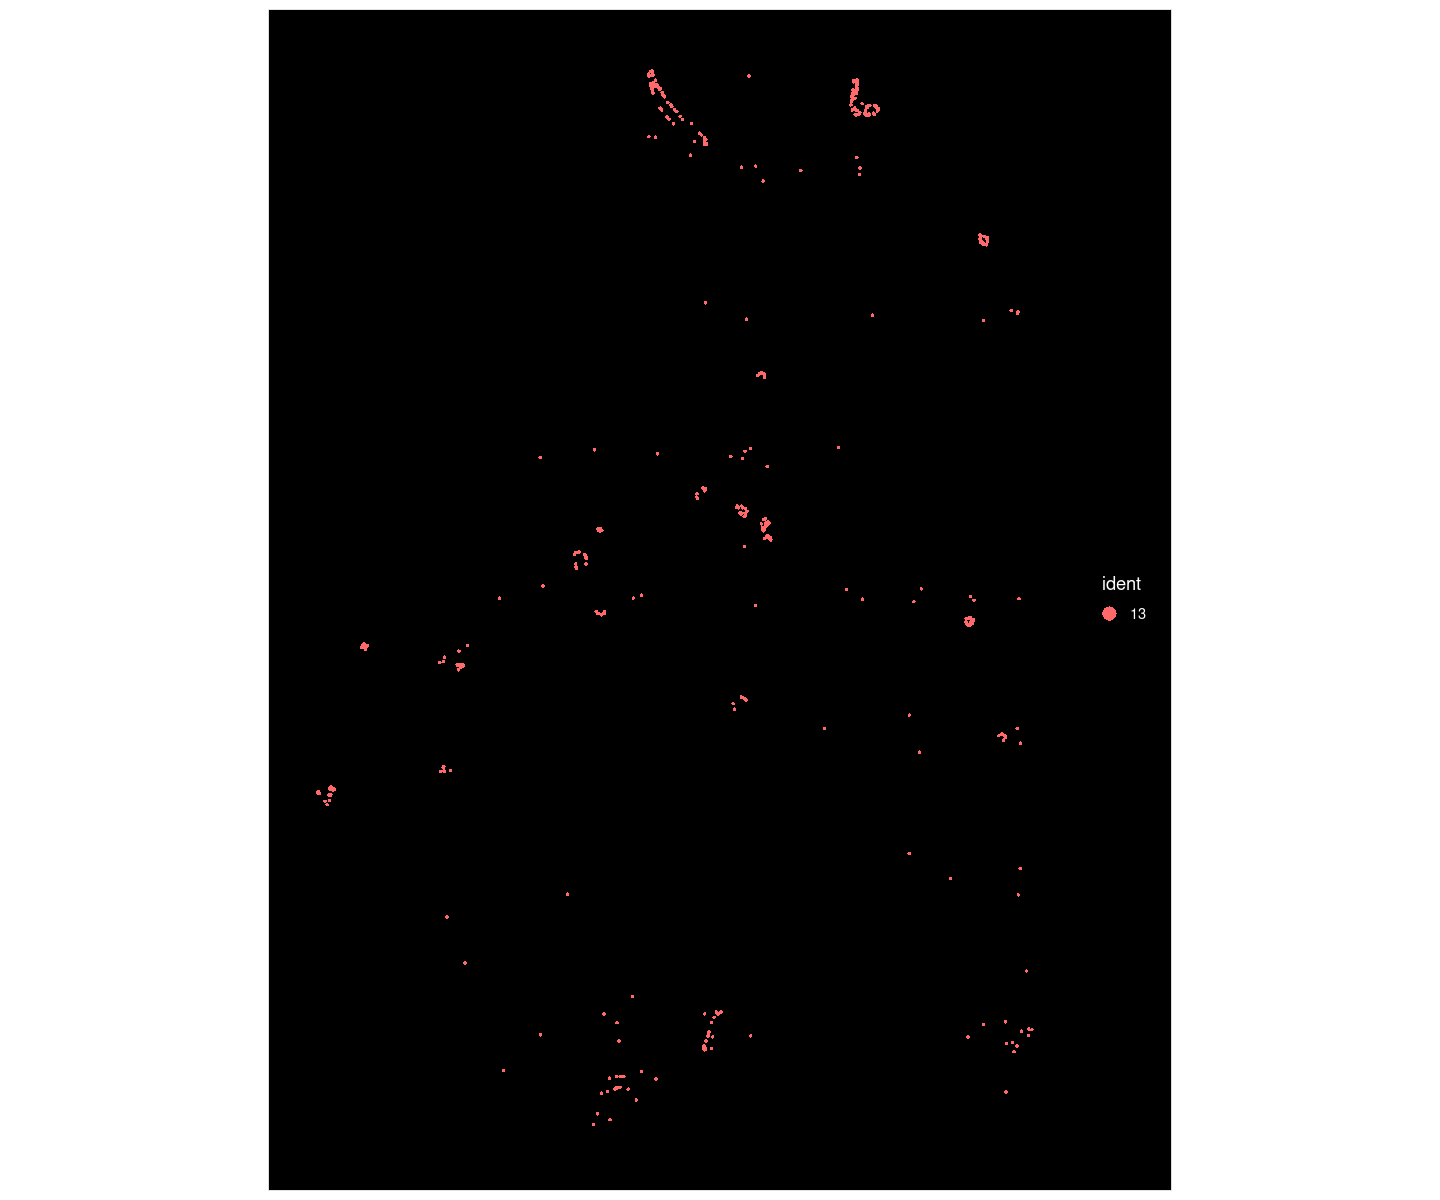

In [32]:
options(repr.plot.height = 10,
        repr.plot.width = 12)

Idents(codex.obj) <- "seurat_clusters"

sub <- subset(codex.obj, subset = seurat_clusters %in% c("13"))
ImageDimPlot(sub, cols = "parade", size = 1)

In [33]:
#not epithalial based on location
codex.obj <- subset(codex.obj, subset=seurat_clusters %in% c("0",
                                                            "1",
                                                             "2",
                                                             "3",
                                                             "4",
                                                             "5",
                                                             "6",
                                                             "7",
                                                            "8",
                                                             "10",
                                                            "11",
                                                             "12"), invert = T)

codex.obj

Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Seurat objects”


An object of class Seurat 
12 features across 1414 samples within 1 assay 
Active assay: Multiplex (12 features, 5 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap
 1 spatial field of view present: fov

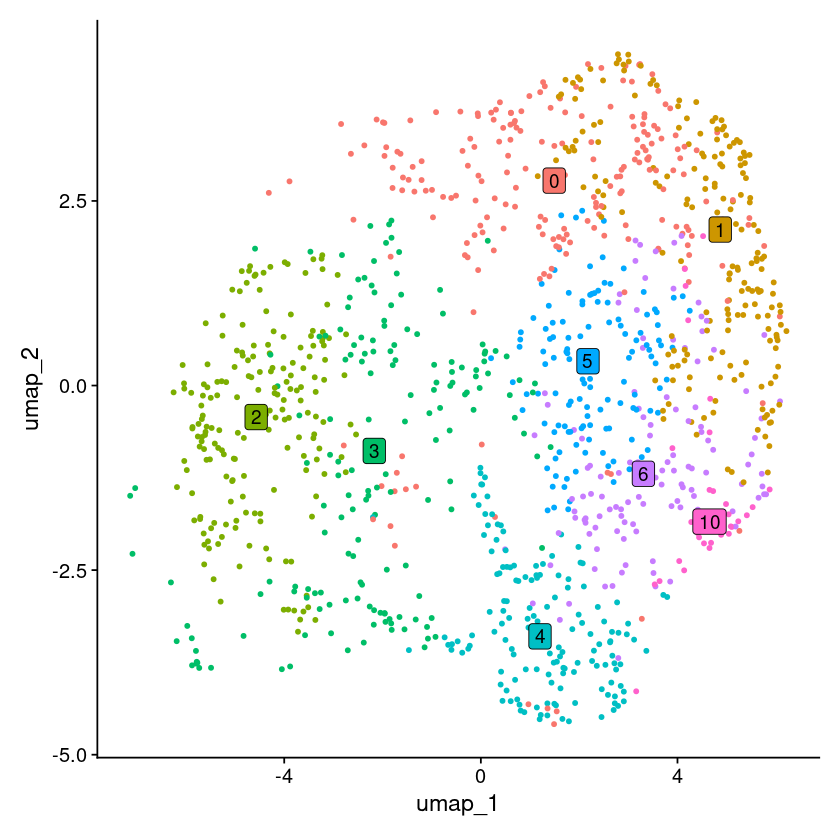

In [46]:
codex.obj <- NormalizeData(object = codex.obj, normalization.method = "CLR", margin = 2)
codex.obj <- ScaleData(codex.obj)
VariableFeatures(codex.obj) <- variable_genes  # since the panel is small, treat these features as variable.
codex.obj <- RunPCA(object = codex.obj, npcs = 4, verbose = FALSE)
codex.obj <- FindNeighbors(object = codex.obj, dims = 1:4, verbose = FALSE)
codex.obj <- FindClusters(object = codex.obj, verbose = FALSE, resolution = 1, n.start = 1)
codex.obj <- RunUMAP(object = codex.obj, dims = 1:4, verbose = FALSE)

options(repr.plot.height = 7,
        repr.plot.width = 7)
DimPlot(codex.obj, label = TRUE, label.box = TRUE) + NoLegend()

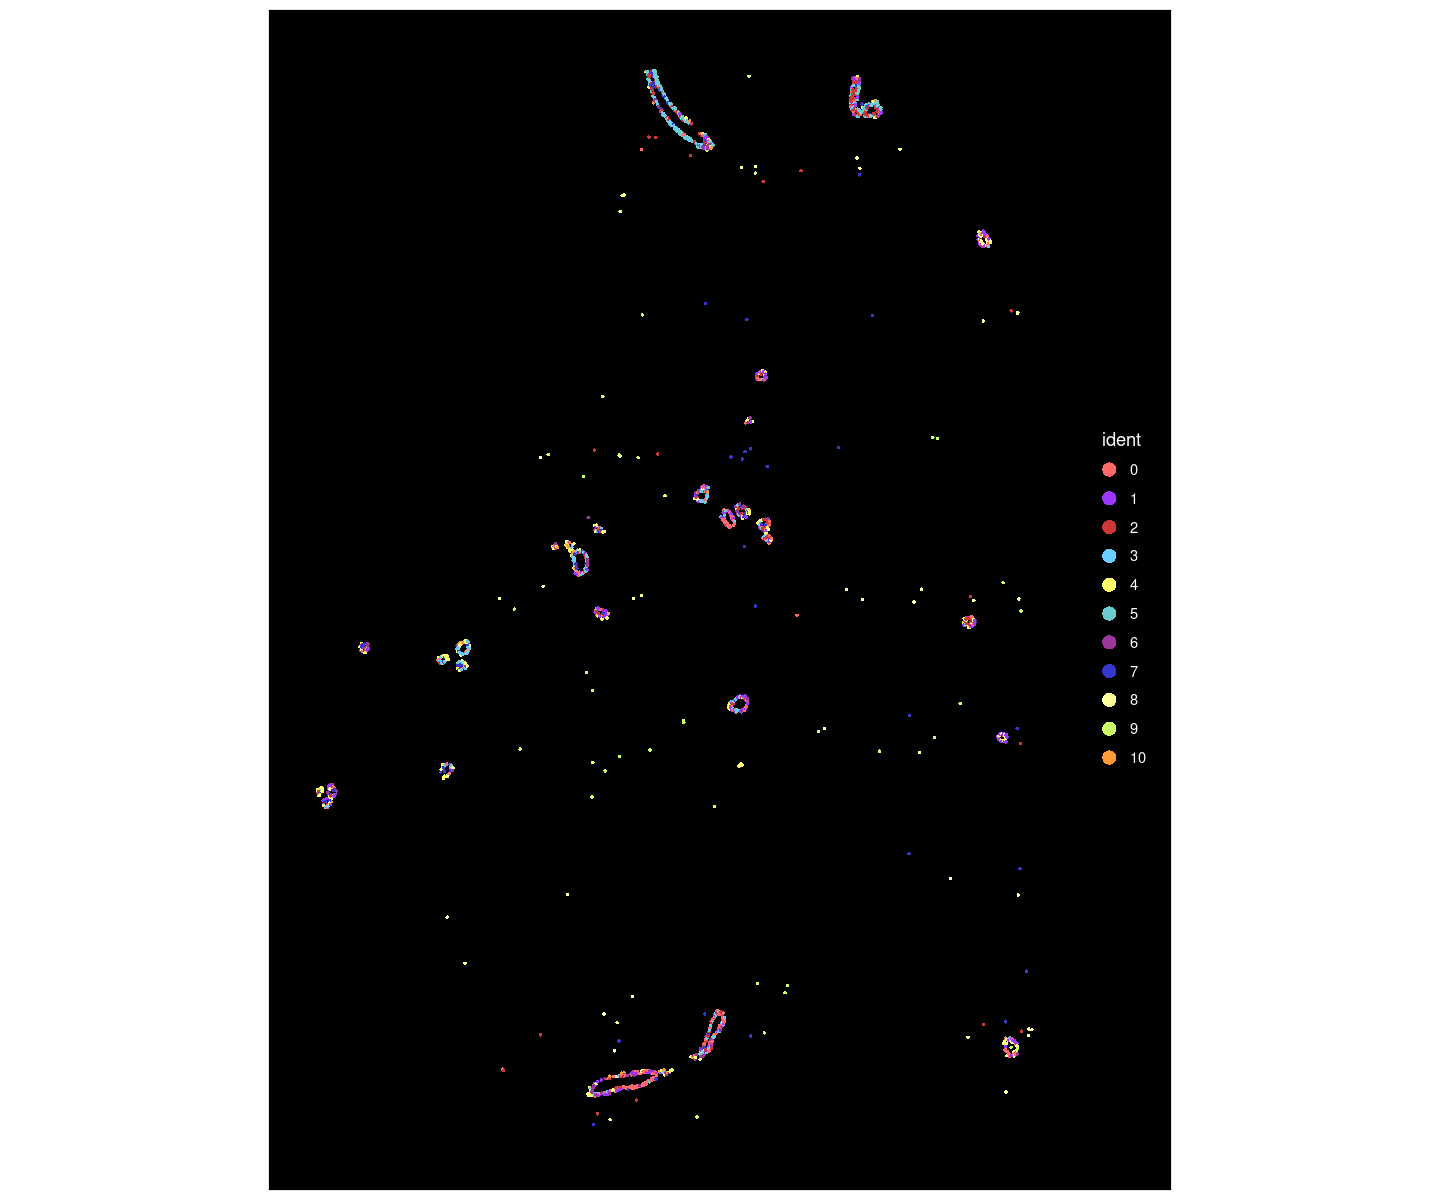

In [37]:
options(repr.plot.height = 10,
        repr.plot.width = 12)

Idents(codex.obj) <- "seurat_clusters"

ImageDimPlot(codex.obj, cols = "parade", size = 1)

Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Seurat objects”


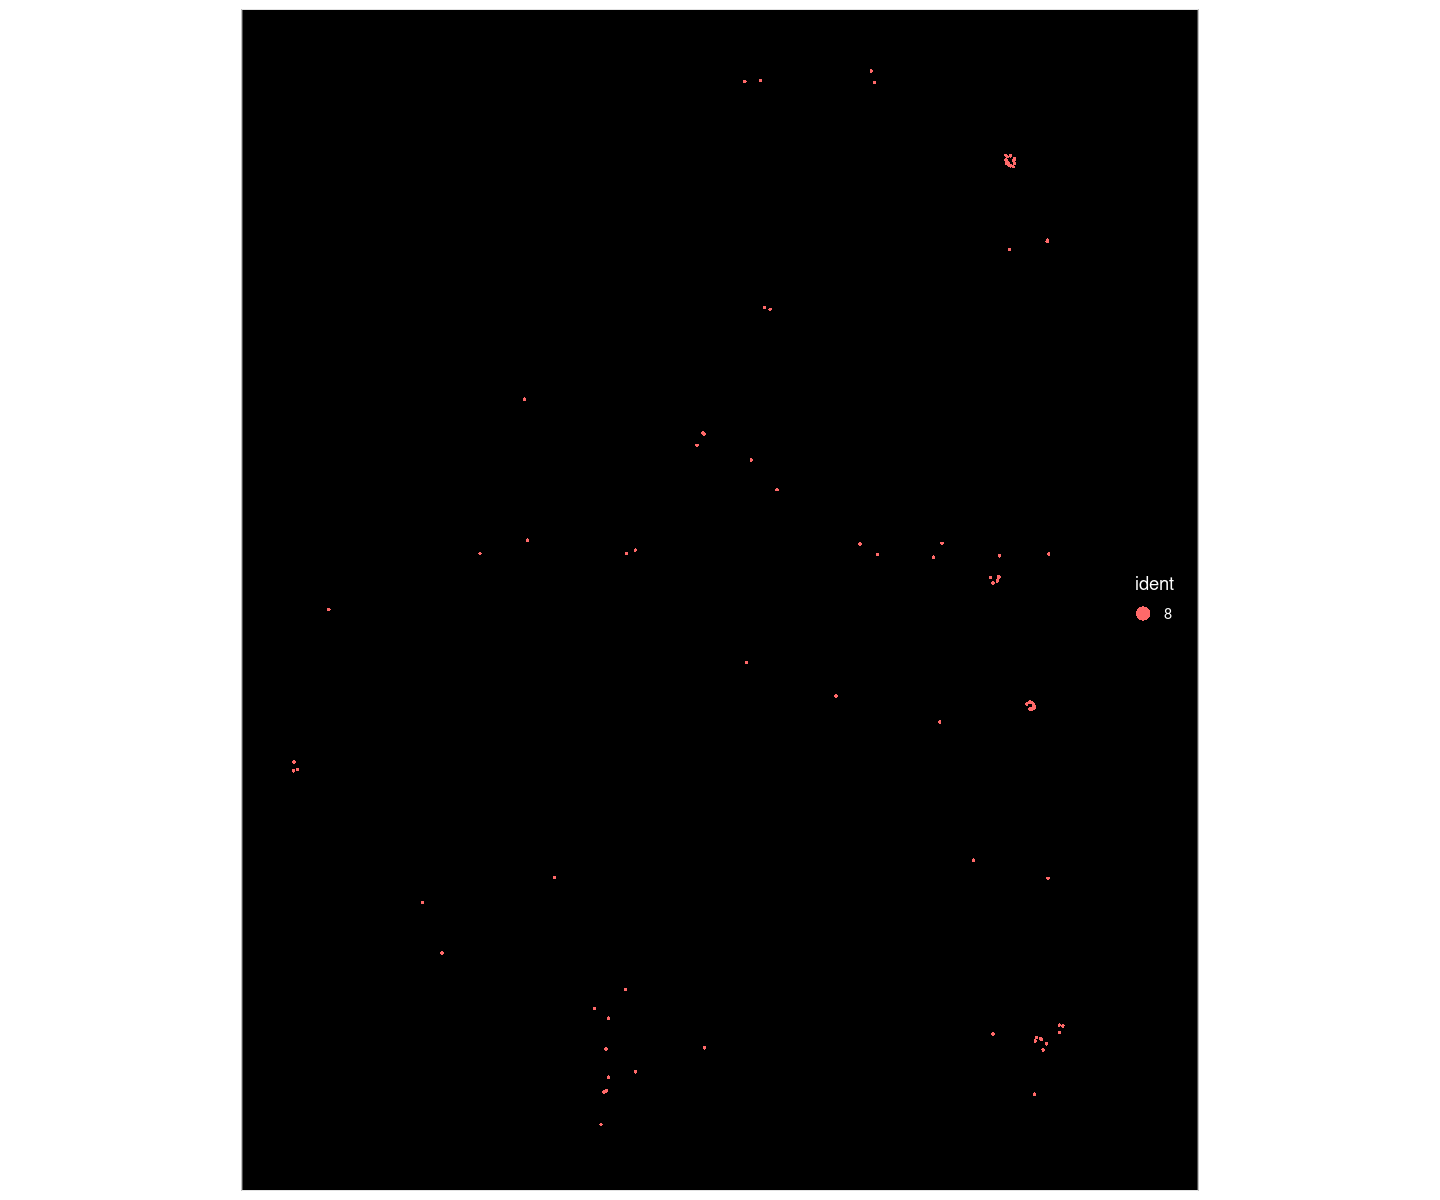

In [42]:
options(repr.plot.height = 10,
        repr.plot.width = 12)

Idents(codex.obj) <- "seurat_clusters"

sub <- subset(codex.obj, subset = seurat_clusters %in% c("8"))
ImageDimPlot(sub, cols = "parade", size = 1)

In [43]:
## not epithelial based on location: 0 (stroma)
codex.obj <- subset(codex.obj, subset=seurat_clusters %in% c("7","8","9"), invert = T)

Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Seurat objects”


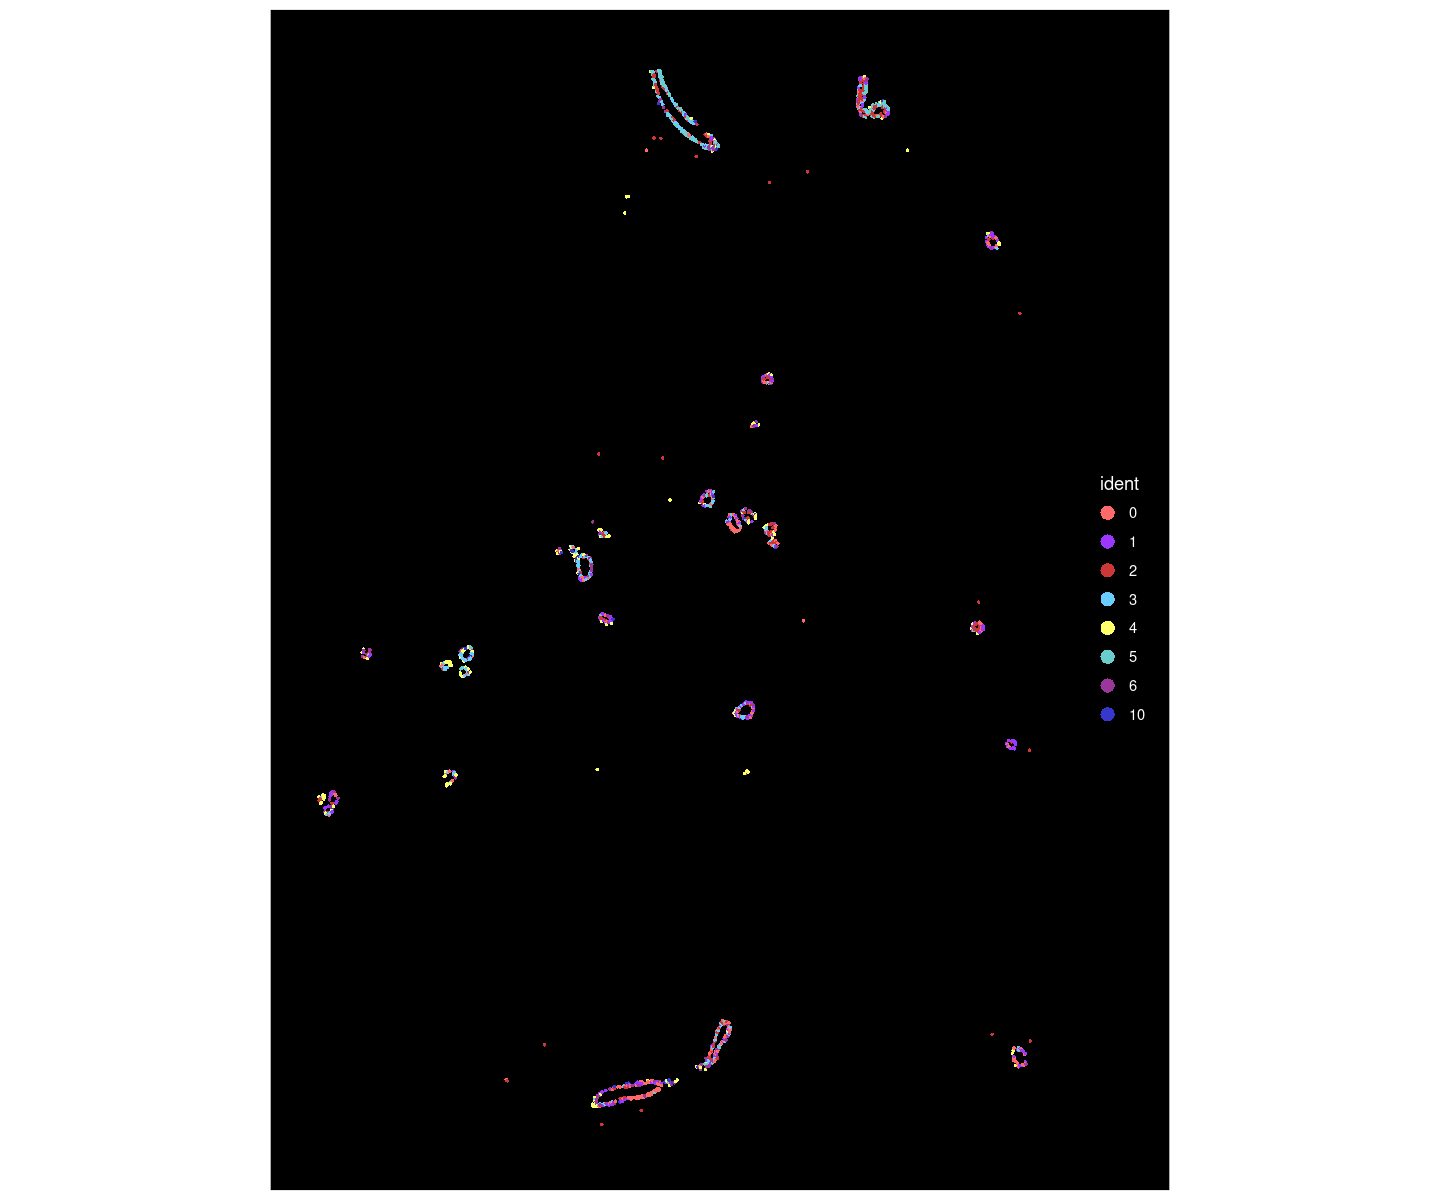

In [44]:
options(repr.plot.height = 10,
        repr.plot.width = 12)

Idents(codex.obj) <- "seurat_clusters"

ImageDimPlot(codex.obj, cols = "parade", size = 1)

In [45]:
codex.obj

An object of class Seurat 
12 features across 1178 samples within 1 assay 
Active assay: Multiplex (12 features, 5 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap
 1 spatial field of view present: fov

In [ ]:
### Putative epithelial

Normalizing layer: counts

Normalizing across cells

Centering and scaling data matrix

Warning message in irlba(A = t(x = object), nv = npcs, ...):
“You're computing too large a percentage of total singular values, use a standard svd instead.”


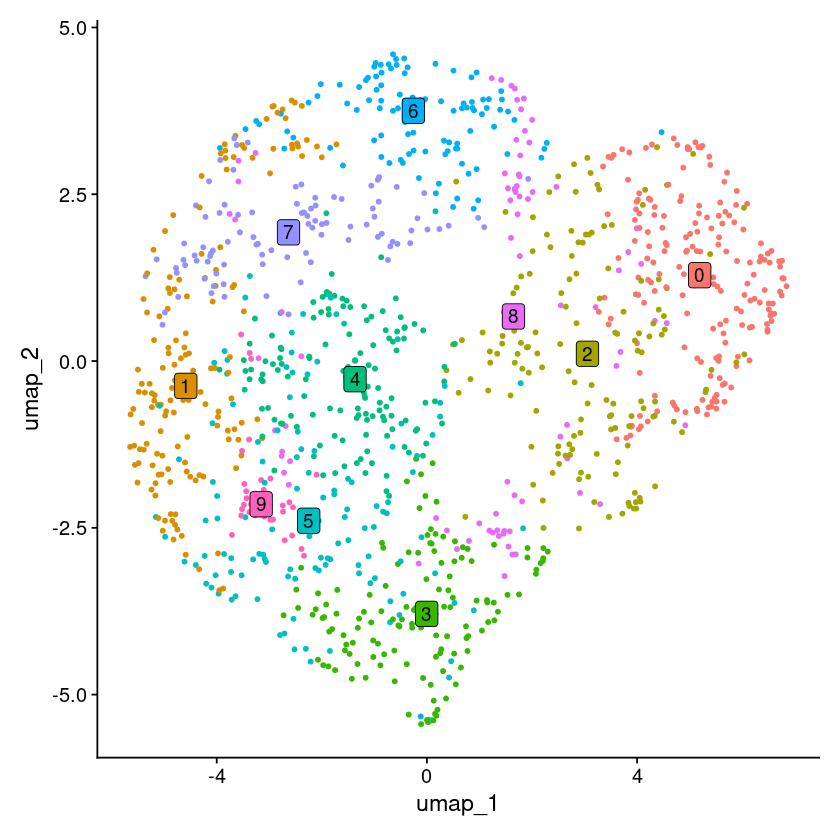

In [47]:
codex.obj <- NormalizeData(object = codex.obj, normalization.method = "CLR", margin = 2)
codex.obj <- ScaleData(codex.obj)
VariableFeatures(codex.obj) <- variable_genes  # since the panel is small, treat these features as variable.
codex.obj <- RunPCA(object = codex.obj, npcs = 4, verbose = FALSE)
codex.obj <- FindNeighbors(object = codex.obj, dims = 1:4, verbose = FALSE)
codex.obj <- FindClusters(object = codex.obj, verbose = FALSE, resolution = 1, n.start = 1)
codex.obj <- RunUMAP(object = codex.obj, dims = 1:4, verbose = FALSE)

options(repr.plot.height = 7,
        repr.plot.width = 7)
DimPlot(codex.obj, label = TRUE, label.box = TRUE) + NoLegend()

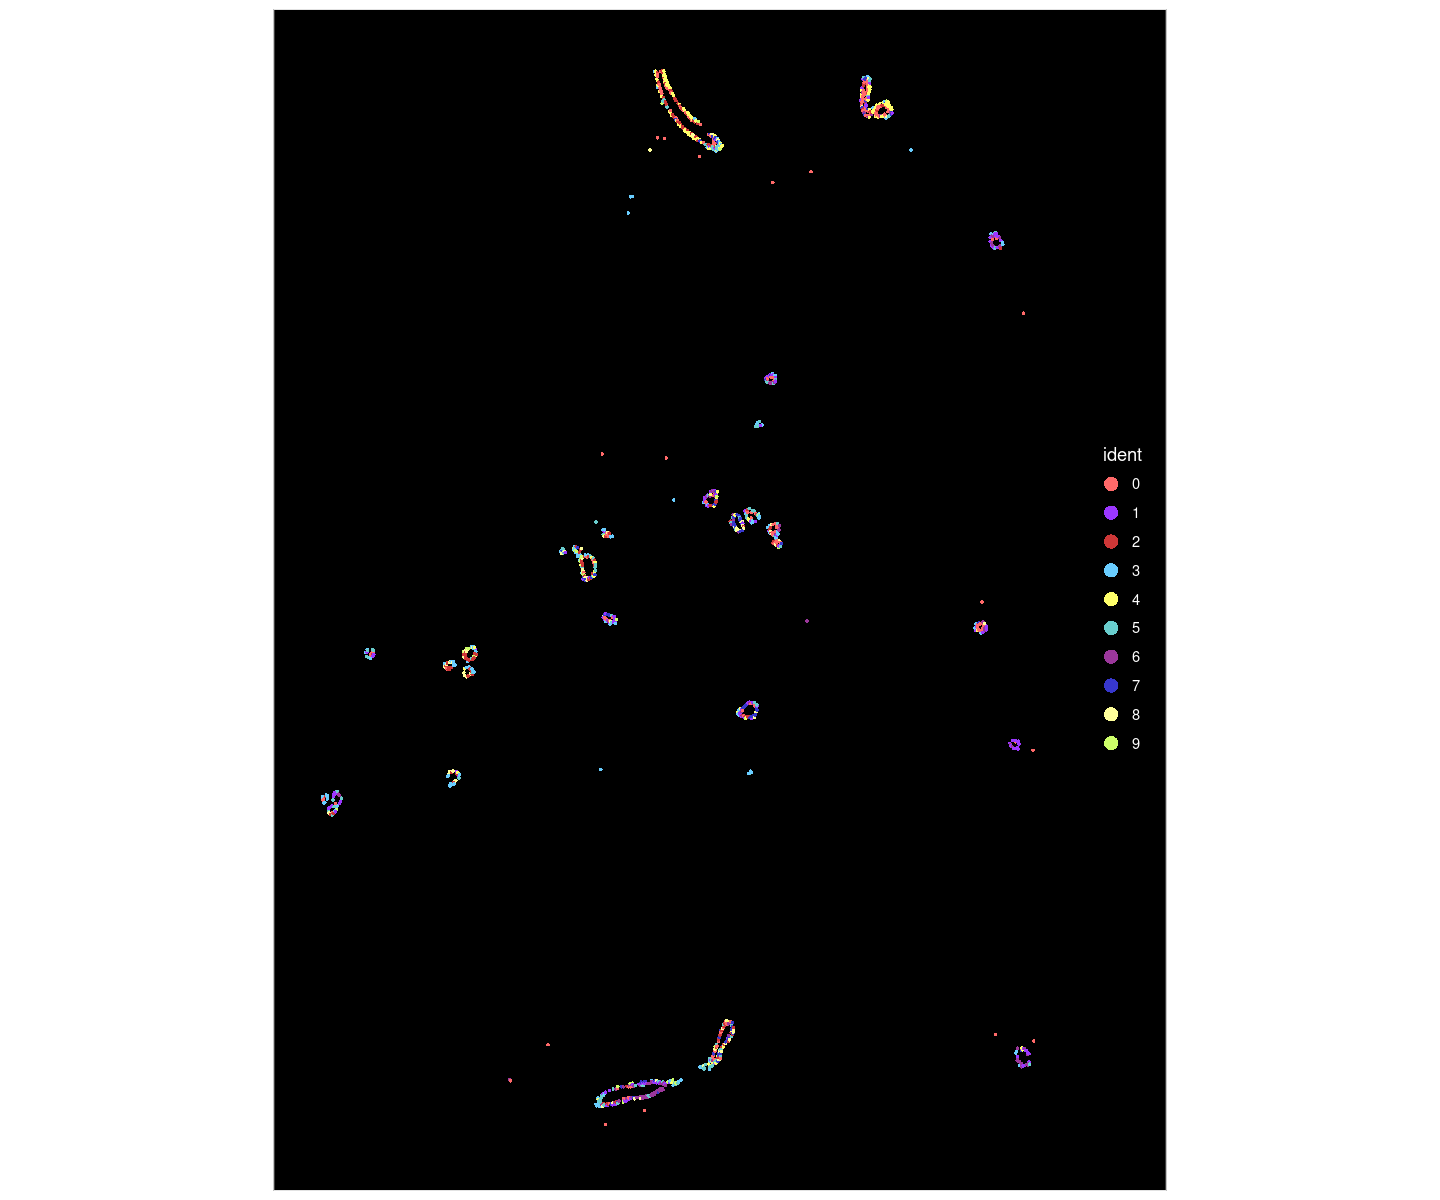

In [48]:
options(repr.plot.height = 10,
        repr.plot.width = 12)

Idents(codex.obj) <- "seurat_clusters"

ImageDimPlot(codex.obj, cols = "parade", size = 1)

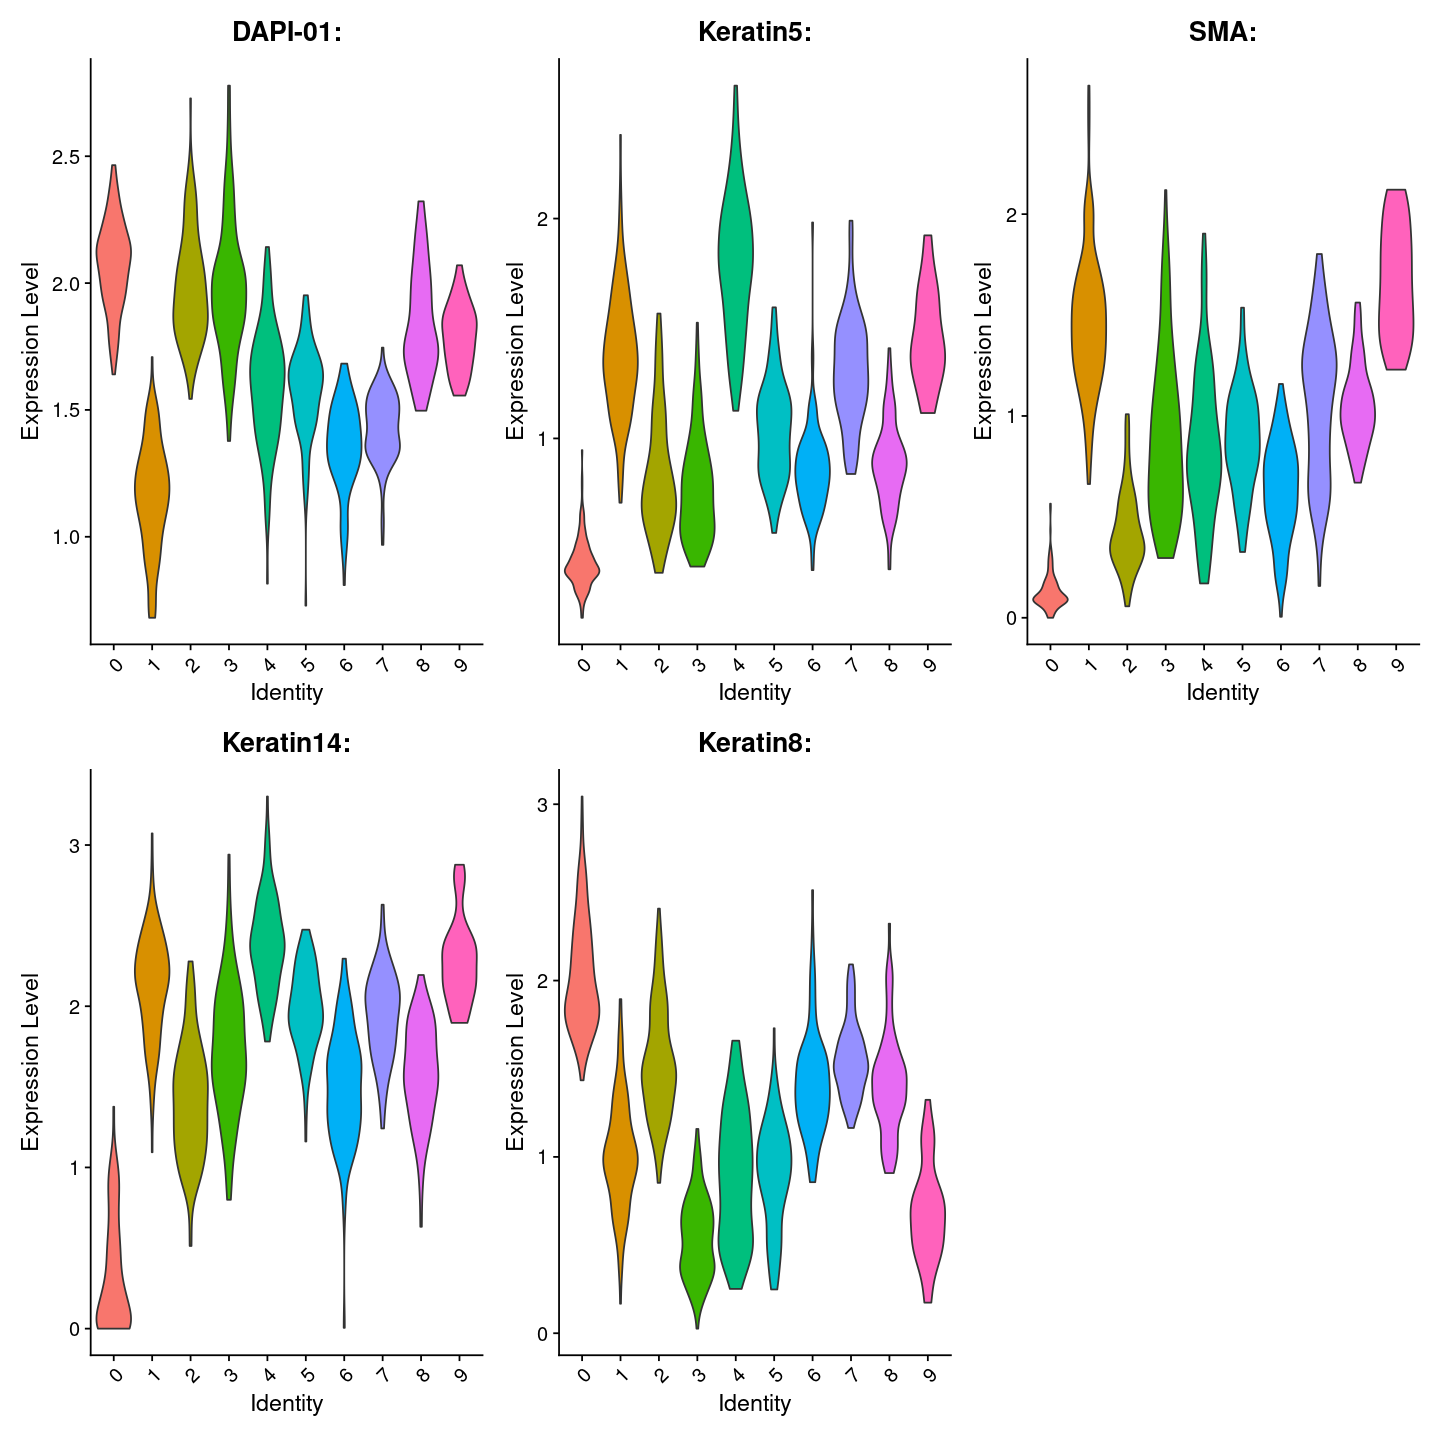

In [51]:
options(repr.plot.height = 12,
        repr.plot.width = 12)

VlnPlot(codex.obj, features = genes, pt.size=0)

In [52]:
codex.obj

An object of class Seurat 
12 features across 1178 samples within 1 assay 
Active assay: Multiplex (12 features, 5 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap
 1 spatial field of view present: fov

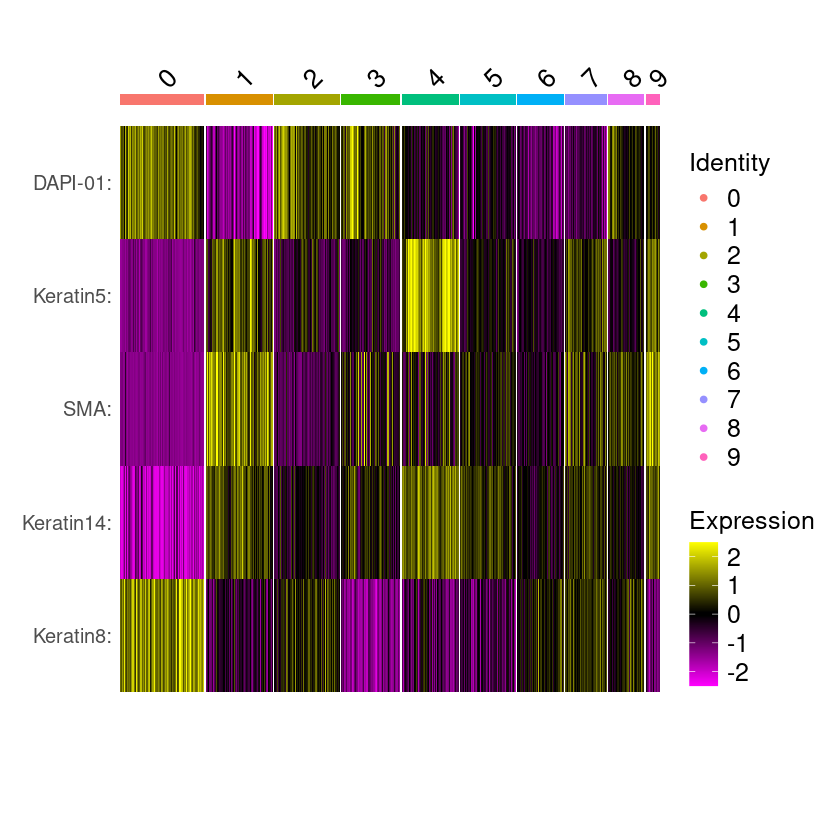

In [50]:
options(repr.plot.height = 7,
        repr.plot.width = 7)

DoHeatmap(subset(codex.obj, downsample=500), features = genes)+ 
    theme(text = element_text(size = 15))+ 
theme(legend.text  = element_text(size = 15)) 

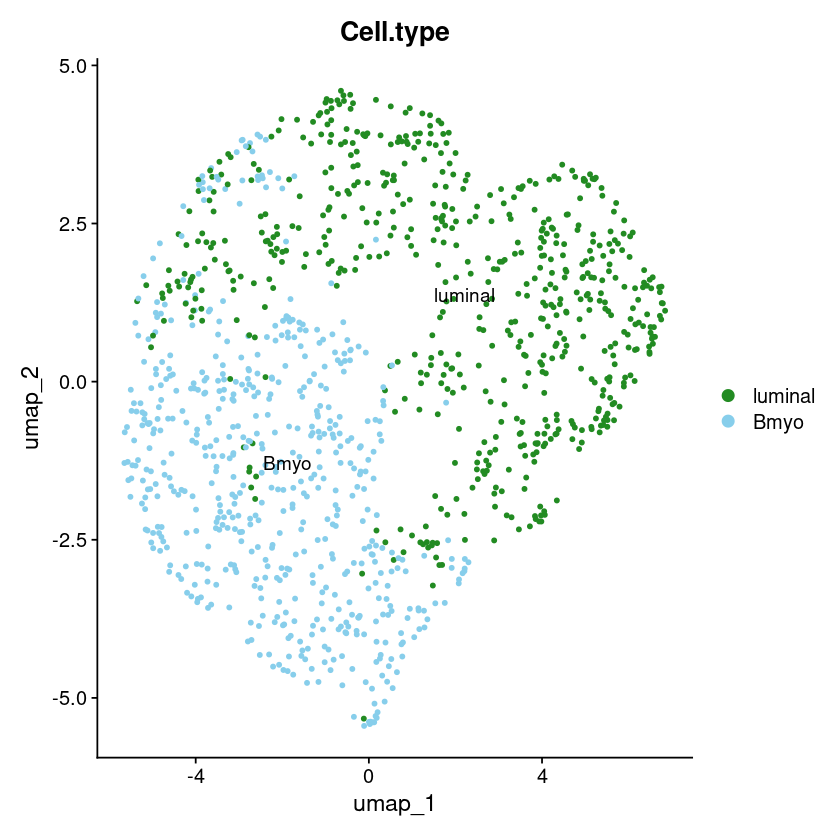

In [54]:
Idents(codex.obj) <- "seurat_clusters"
codex.obj <- RenameIdents(object = codex.obj, 
                            `0` = "luminal", 
                            `1` = "Bmyo", 
                            `2` = "luminal", 
                            `3` = "Bmyo",
                            `4` = "Bmyo",
                            `5` = "Bmyo",
                            `6` = "luminal", 
                            `7` = "luminal",
                            `8` = "luminal",
                            `9` = "Bmyo")
codex.obj$Cell.type <- codex.obj@active.ident

options(repr.plot.height = 7,
        repr.plot.width = 7)

DimPlot(codex.obj, group.by = "Cell.type", label = T, repel=T,cols=c("forestgreen","skyblue"))

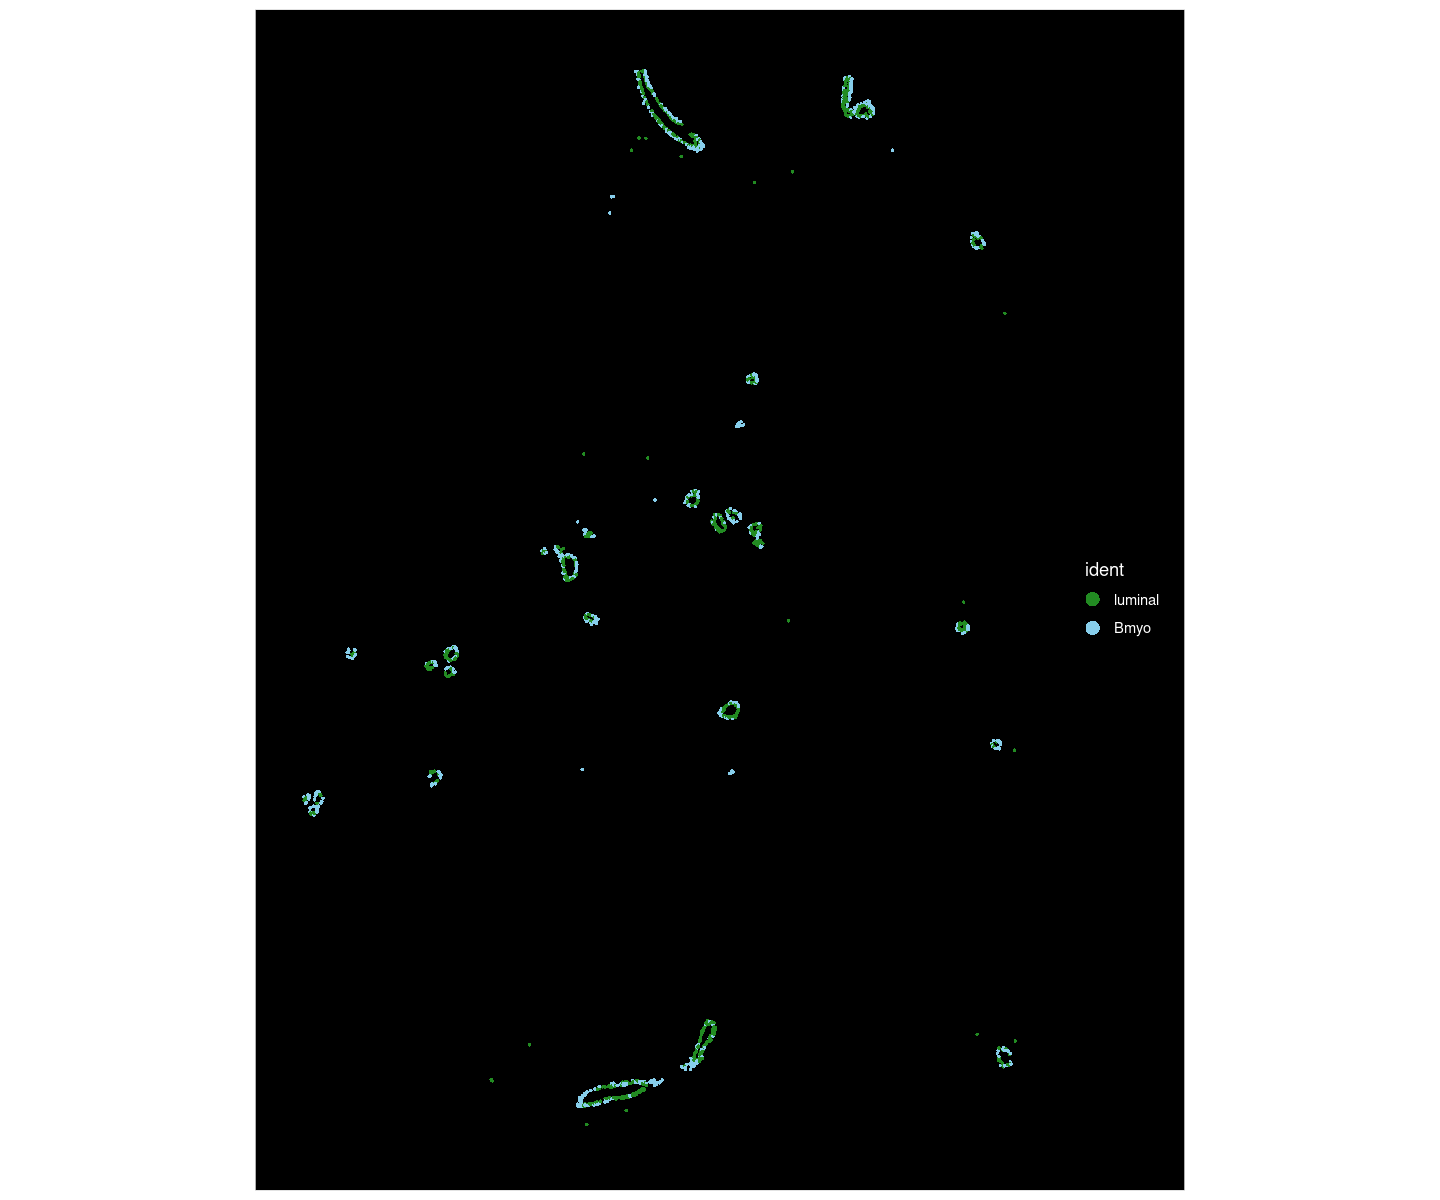

In [55]:
options(repr.plot.height = 10,
        repr.plot.width = 12)

Idents(codex.obj) <- "Cell.type"

ImageDimPlot(codex.obj, cols=c("forestgreen","skyblue"), size = 1)

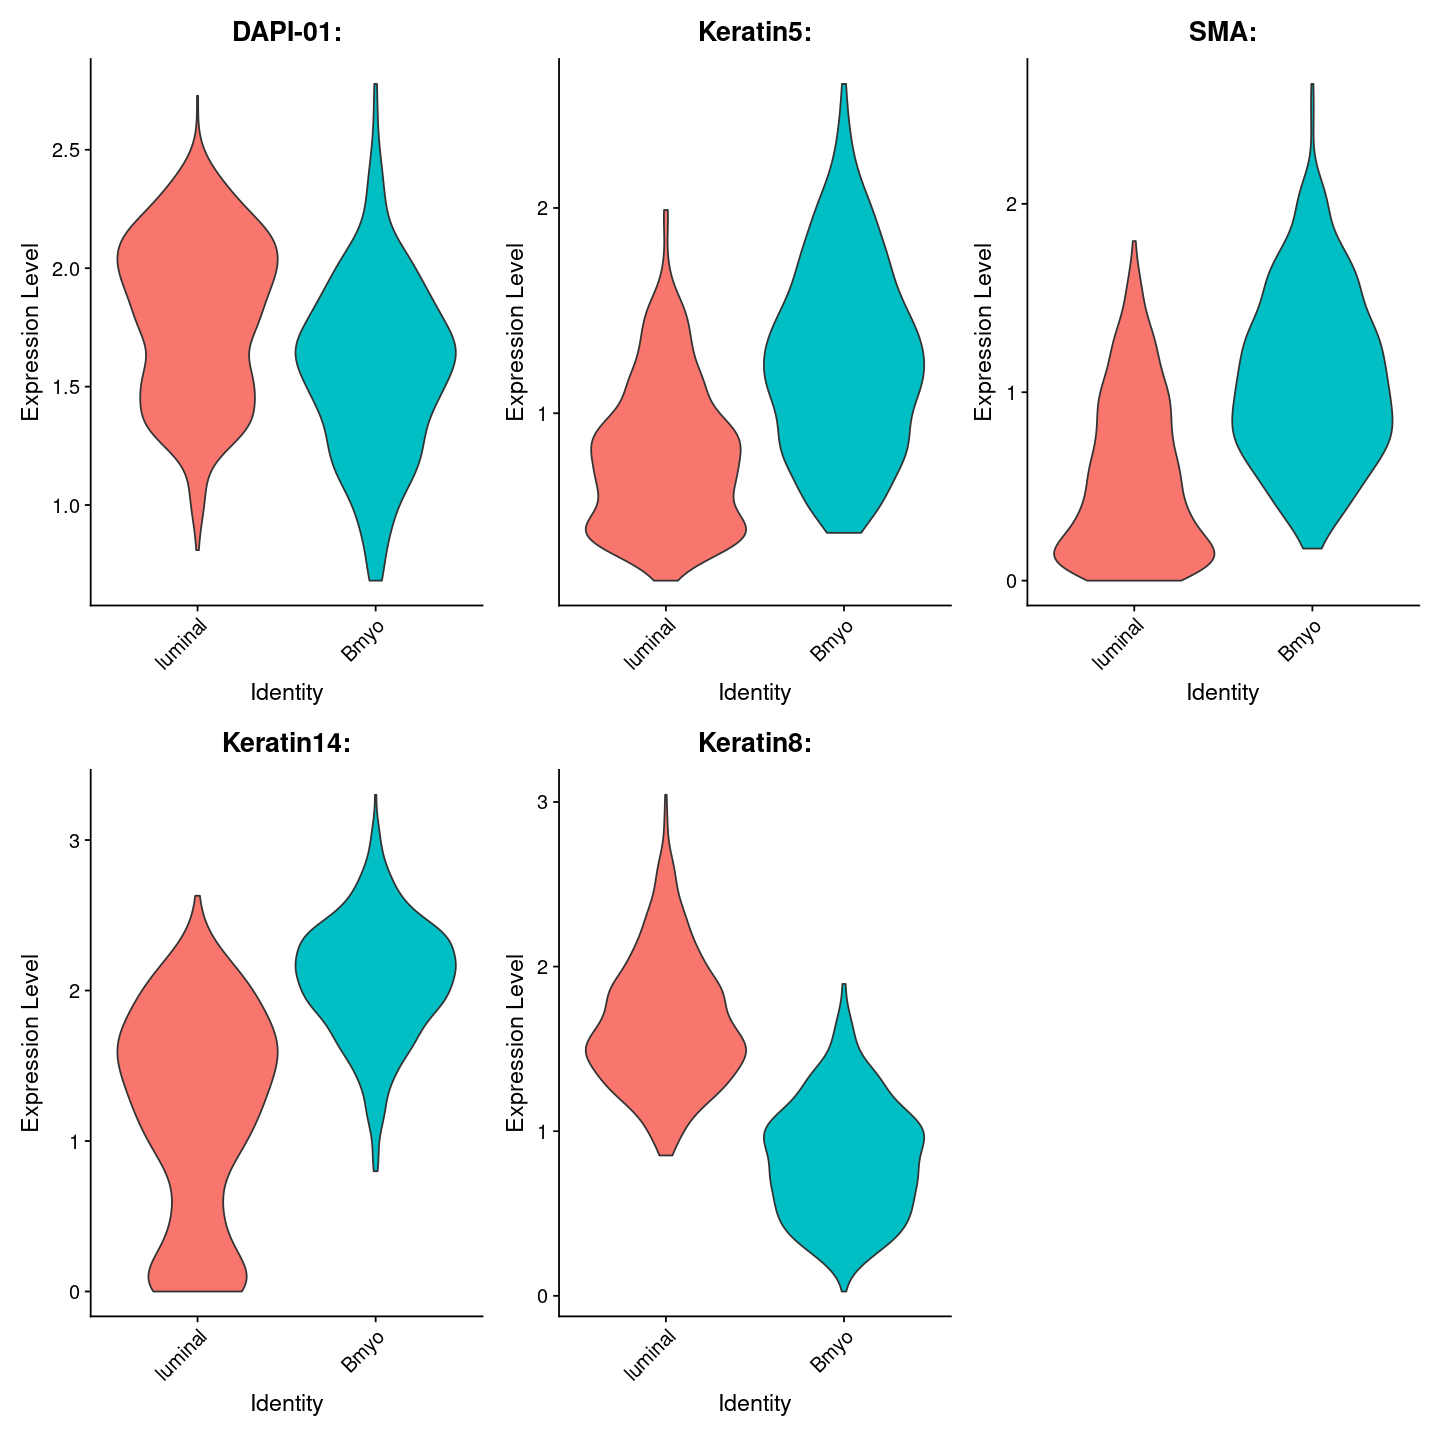

In [57]:
options(repr.plot.height = 12,
        repr.plot.width = 12)

VlnPlot(codex.obj, features = genes, pt.size=0)

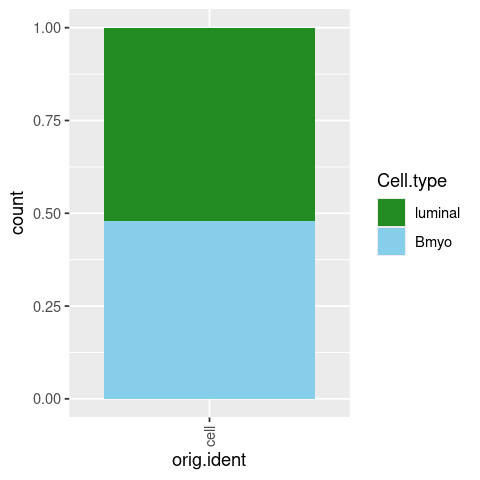

In [58]:
options(repr.plot.height = 4,repr.plot.width = 4)
#pdf("tum2_proportions.pdf",width=3,height=3)
ggplot(codex.obj@meta.data, aes(x=orig.ident, fill=Cell.type)) + geom_bar(position = "fill") + 
theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))+ 
scale_fill_manual(values=c("forestgreen","skyblue"))
#dev.off()

In [56]:
saveRDS(codex.obj,"wt_1.rds")

# Identifying basal-no-myo & hybrid cells

In [3]:
codex.obj <- readRDS("wt_1.rds")

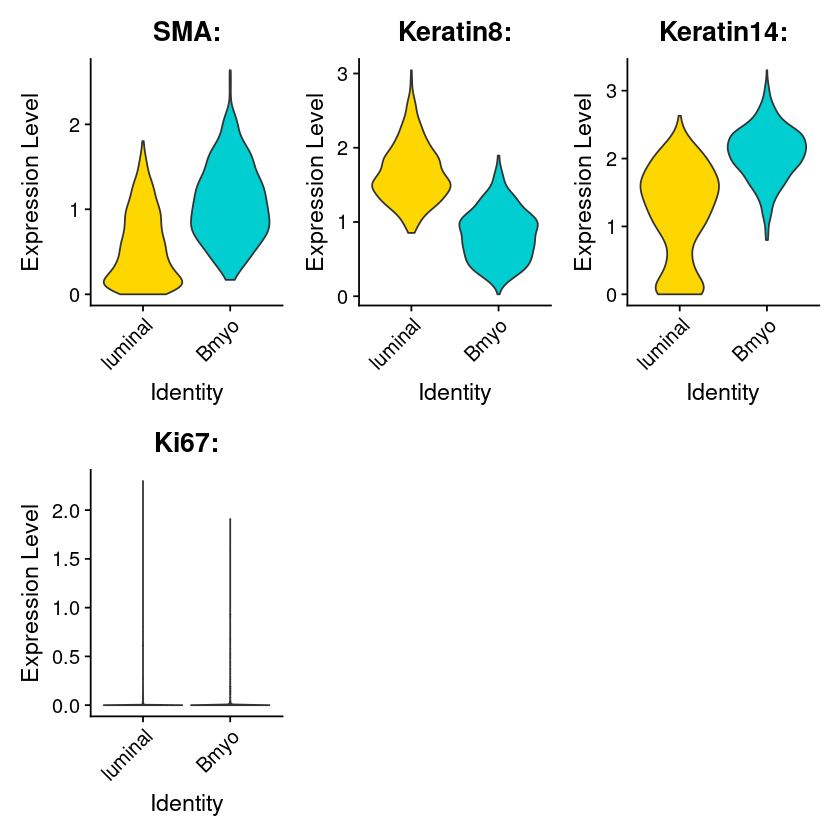

In [4]:
Idents(codex.obj) <- "Cell.type"
VlnPlot(codex.obj, features = c("SMA:","Keratin8:","Keratin14:","Ki67:"), pt.size=0, cols=c("gold","darkturquoise"))

In [5]:
#codex.obj$basal_no_myo <- NULL

# 1. Get the names of cells expressing "GeneName" above a threshold
basal_no_myo <- WhichCells(object = codex.obj, expression = (Cell.type == "Bmyo") & (`SMA:` < 0.25))

# 2. Create/Update a column based on the condition
codex.obj$basal_no_myo <- ifelse(
  colnames(codex.obj) %in% basal_no_myo, 
  "basal_no_myo",               # Name for cells below the threshold
  as.character(codex.obj$Cell.type) # Keep original name for cells above threshold
)

In [6]:
lum <- subset(codex.obj, subset = Cell.type == 'luminal')
gene_data <- FetchData(lum, vars = "Keratin8:")
median_K8 <- mean(gene_data$`Keratin8:`)
median_K8

basal <- subset(codex.obj, subset = Cell.type == 'Bmyo')
gene_data <- FetchData(basal, vars = "Keratin14:")
median_K14 <- mean(gene_data$`Keratin14:`)
median_K14

Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Seurat objects”


[1] 1.656492

Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating Centroids objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating FOV objects”
Warning message:
“Not validating Seurat objects”


[1] 2.072737

In [7]:
#codex.obj$Cell.type.basal.hybrid <- NULL

# 1. Get the names of cells expressing "GeneName" above a threshold
hybrid <- WhichCells(object = codex.obj, expression = (`Keratin8:` > median_K8) & (`Keratin14:` > median_K14))

# 2. Create/Update a column based on the condition
codex.obj$Cell.type.basal.hybrid <- ifelse(
  colnames(codex.obj) %in% hybrid, 
  "hybrid",               # Name for cells below the threshold
  as.character(codex.obj$basal_no_myo) # Keep original name for cells above threshold
)

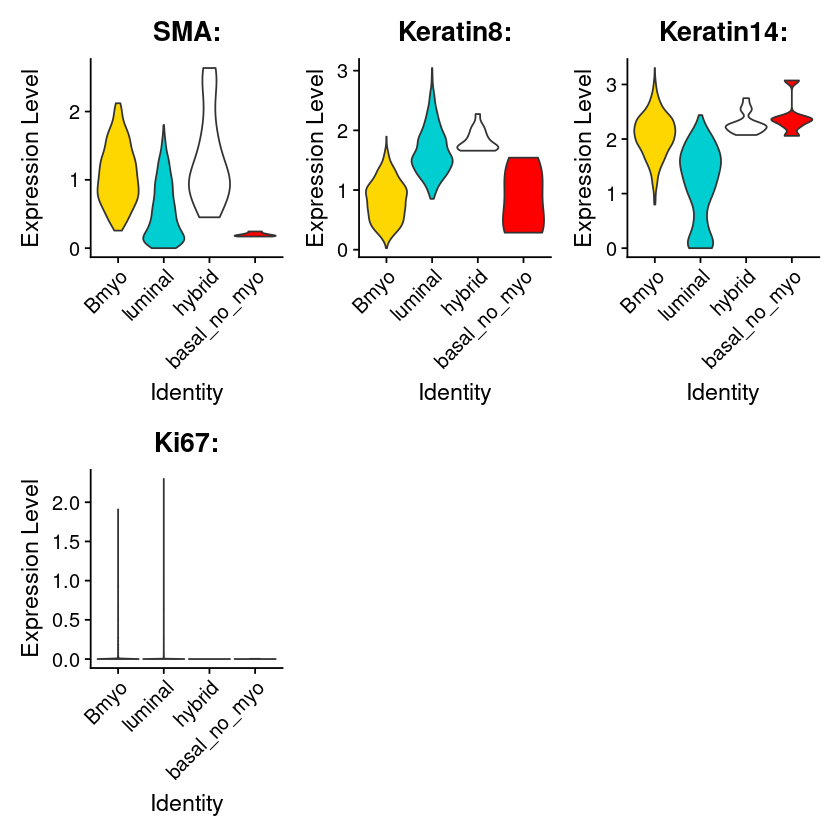

In [12]:
Idents(codex.obj) <- "Cell.type.basal.hybrid"
VlnPlot(codex.obj, features = c("SMA:","Keratin8:","Keratin14:","Ki67:"), pt.size=0, cols=c("gold","darkturquoise","white","red"))

In [13]:
codex.obj

An object of class Seurat 
12 features across 1178 samples within 1 assay 
Active assay: Multiplex (12 features, 5 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap
 1 spatial field of view present: fov

In [14]:
table(codex.obj$Cell.type.basal.hybrid)


        Bmyo basal_no_myo       hybrid      luminal 
         555            6           18          599 

In [15]:
saveRDS(codex.obj,"wt_1.rds")

# Defining normal-like and hyperplastic ROIs

In [3]:
codex.obj <- readRDS("wt_1.rds")

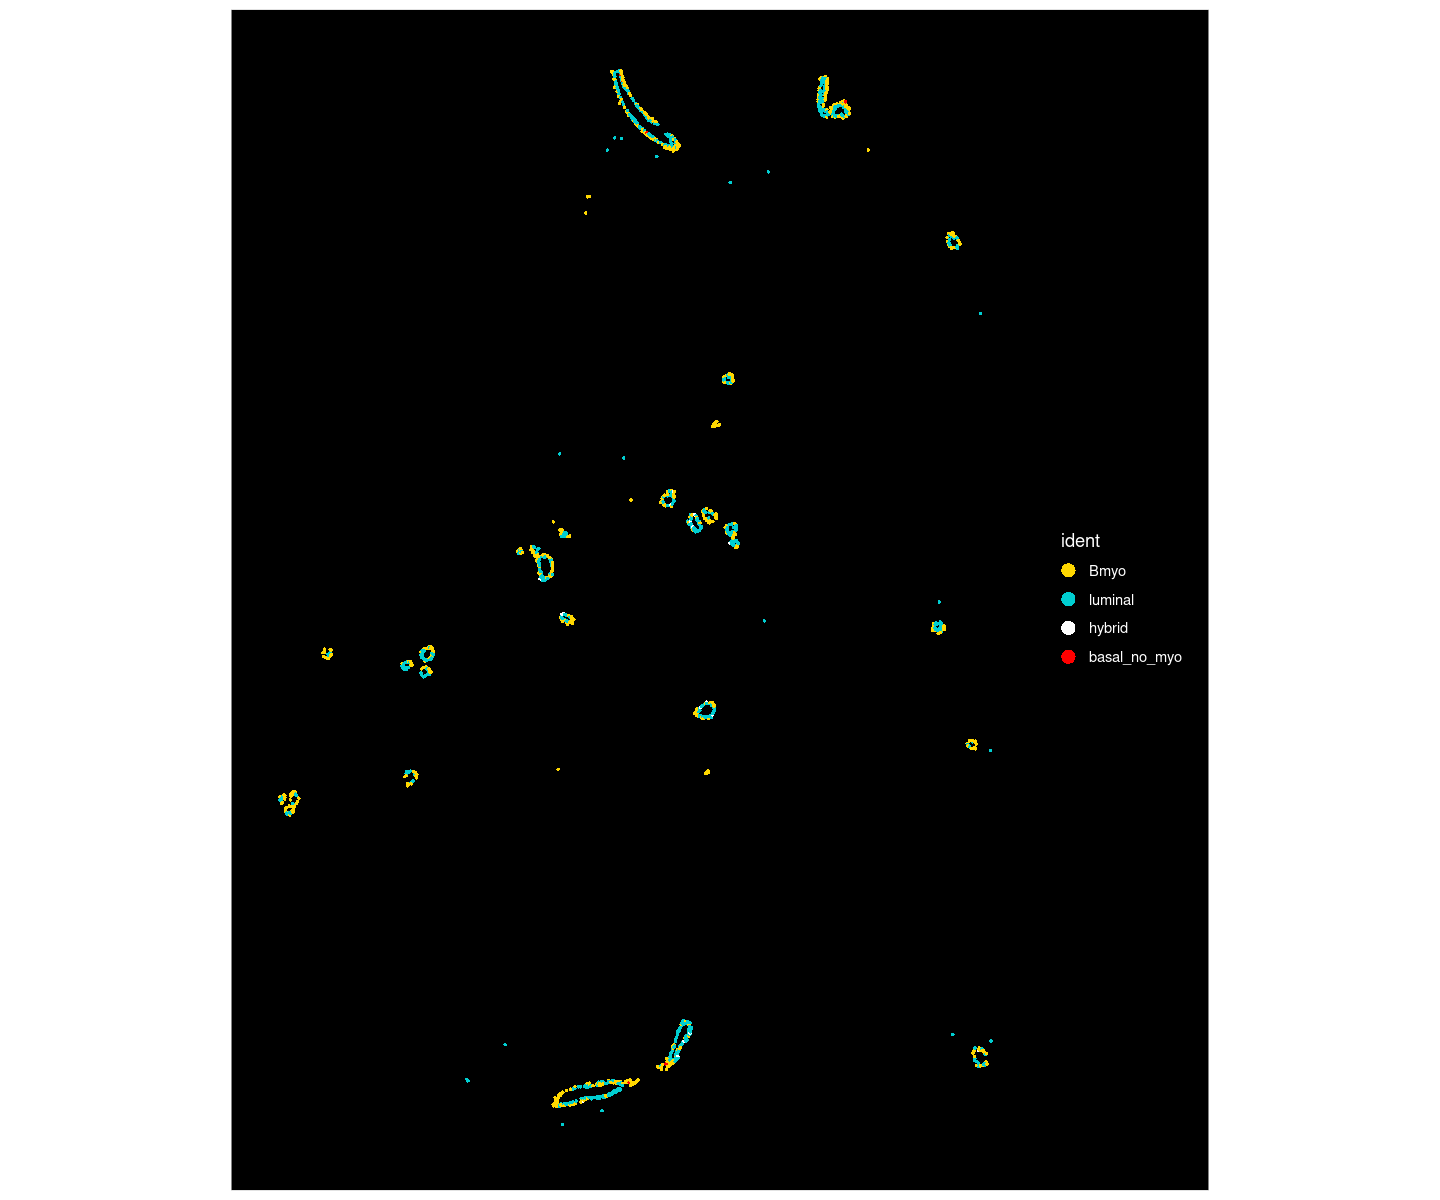

In [4]:
options(repr.plot.height = 10,
        repr.plot.width = 12)

Idents(codex.obj) <- "Cell.type.basal.hybrid"

ImageDimPlot(codex.obj, cols=c("gold","darkturquoise","white","red"), size = 1)

In [4]:
# Define your specific center coordinate and radius
coords <- SeuratObject::GetTissueCoordinates(object = codex.obj, fov = "fov")

x0 <- 2000  # Replace with your x coordinate
y0 <- 2353  # Replace with your y coordinate
rad <- 565   # Replace with your desired radius

x2 <- 3629  # Replace with your x coordinate
y2 <- 2600  # Replace with your y coordinate

x3 <- 1329  # Replace with your x coordinate
y3 <- 1300  # Replace with your y coordinate


# Calculate distance and identify cells
coords$distance <- sqrt((coords$x - x0)^2 + (coords$y - y0)^2)
selected_cells <- coords[which(coords$distance <= rad), ]
selected_cells <- selected_cells$cell


# Calculate distance and identify cells
coords$distance2 <- sqrt((coords$x - x2)^2 + (coords$y - y2)^2)
selected_cells2 <- coords[which(coords$distance2 <= rad), ]
selected_cells2 <- selected_cells2$cell

# Calculate distance and identify cells
coords$distance3 <- sqrt((coords$x - x3)^2 + (coords$y - y3)^2)
selected_cells3 <- coords[which(coords$distance3 <= rad), ]
selected_cells3 <- selected_cells3$cell

#~~~~~~~~~~~~~~~~~~~

#x7 <- 500  # Replace with your x coordinate
#y7 <- 3450  # Replace with your y coordinate

#x8 <- 500  # Replace with your x coordinate
#y8 <- 2150  # Replace with your y coordinate

#x9 <- 1850  # Replace with your x coordinate
#y9 <- 3500  # Replace with your y coordinate

# Calculate distance and identify cells
#coords$distance7 <- sqrt((coords$x - x7)^2 + (coords$y - y7)^2)
#selected_cells7 <- coords[which(coords$distance7 <= rad), ]
#selected_cells7 <- selected_cells7$cell


# Calculate distance and identify cells
#coords$distance8 <- sqrt((coords$x - x8)^2 + (coords$y - y8)^2)
#selected_cells8 <- coords[which(coords$distance8 <= rad), ]
#selected_cells8 <- selected_cells8$cell

# Calculate distance and identify cells
#coords$distance9 <- sqrt((coords$x - x9)^2 + (coords$y - y9)^2)
#selected_cells9 <- coords[which(coords$distance9 <= rad), ]
#selected_cells9 <- selected_cells9$cell

In [5]:
inside_norm_roi <- c(selected_cells3,selected_cells2,selected_cells)
inside_hyper_roi <- ""

In [8]:
codex.obj$norm_roi_1 <- ifelse(test = Cells(codex.obj) %in% selected_cells, yes = 1, no = 0)

codex.obj$norm_roi_2 <- ifelse(
  colnames(codex.obj) %in% selected_cells2, 
  2,               # Name for cells in the hyperplastic ROI
  as.character(codex.obj$norm_roi_1) # Keep normal our outer name otherwise
)


codex.obj$norm_roi_3 <- ifelse(
  colnames(codex.obj) %in% selected_cells3, 
  3,               # Name for cells in the hyperplastic ROI
  as.character(codex.obj$norm_roi_2) # Keep normal our outer name otherwise
)

In [9]:
table(codex.obj$norm_roi_3)


  0   1   2   3 
388 328 315 147 

In [10]:
codex.obj$norm_roi <- ifelse(test = Cells(codex.obj) %in% inside_norm_roi, yes = 1, no = 0)

In [11]:
table(codex.obj$norm_roi)


  0   1 
388 790 

In [7]:
codex.obj$rois <- ifelse(
  colnames(codex.obj) %in% inside_hyper_roi, 
  2,               # Name for cells in the hyperplastic ROI
  as.character(codex.obj$norm_roi) # Keep normal our outer name otherwise
)

In [8]:
Idents(codex.obj) <- "rois"

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Warning message in ggforce::geom_circle(aes(x0 = y0, y0 = x0, r = rad), color = "white", :
“All aesthetics have length 1, but the data has 1178 rows.
ℹ Did you mean to use `annotate()`?”
Warning message in ggforce::geom_circle(aes(x0 = y2, y0 = x2, r = rad), color = "white", :
“All aesthetics have length 1, but the data has 1178 rows.
ℹ Did you mean to use `annotate()`?”
Warning message in ggforce::geom_circle(aes(x0 = y3, y0 = x3, r = rad), color = "white", :
“All aesthetics have length 1, but the data has 1178 rows.
ℹ Did you mean to use `annotate()`?”


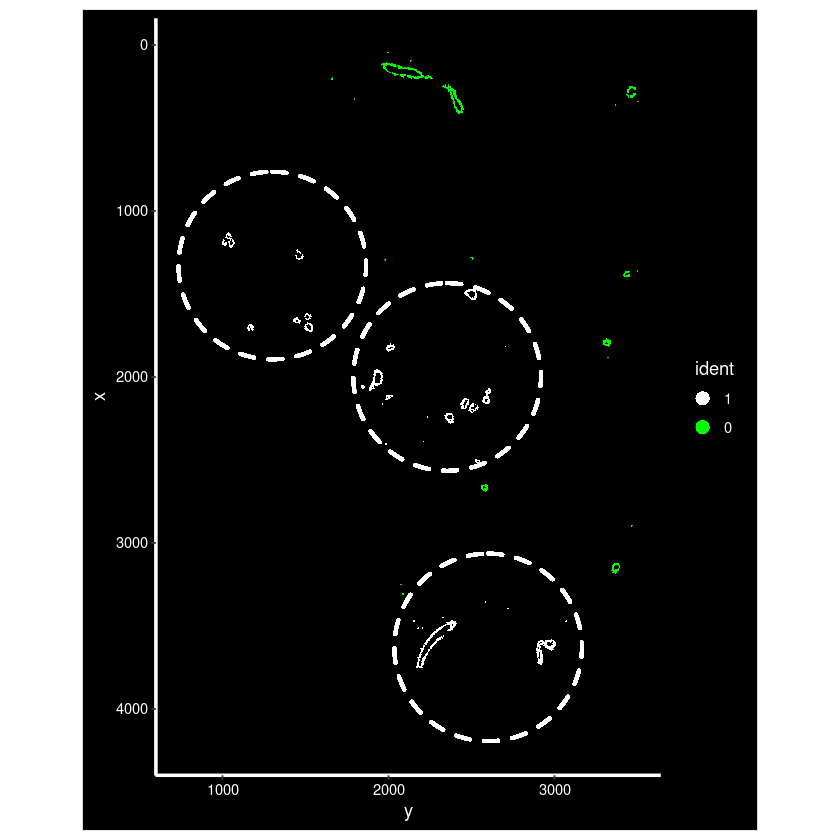

In [9]:
# Highlight the selected cells and add a circle overlay using ggforce
library(ggforce)

# Plot ONLY the cells inside the circle
p <- ImageDimPlot(
  object = codex.obj,
  fov = "fov",cols=c("white","green","red"), axes = TRUE

)+ scale_y_reverse()

# Overlay the exact mathematical circle
p + ggforce::geom_circle(
  aes(x0 = y0, y0 = x0, r = rad), 
  color = "white", 
  linetype = "dashed", 
  size = 1, 
  inherit.aes = FALSE
)+ ggforce::geom_circle(
  aes(x0 = y2, y0 = x2, r = rad), 
  color = "white", 
  linetype = "dashed", 
  size = 1, 
  inherit.aes = FALSE
)+ ggforce::geom_circle(
  aes(x0 = y3, y0 = x3, r = rad), 
  color = "white", 
  linetype = "dashed", 
  size = 1, 
  inherit.aes = FALSE
)

In [12]:
table(codex.obj$rois)


  0   1 
388 790 

In [12]:
table(codex.obj$rois,codex.obj$Cell.type.basal.hybrid)

   
    Bmyo basal_no_myo hybrid luminal
  0  182            2      6     198
  1  373            4     12     401

In [14]:
codex.obj$sample <- "wt_1"

In [13]:
saveRDS(codex.obj,"wt_1.rds")

Warning message in ggforce::geom_circle(aes(x0 = y0, y0 = x0, r = rad), color = "white", :
“All aesthetics have length 1, but the data has 1178 rows.
ℹ Did you mean to use `annotate()`?”
Warning message in ggforce::geom_circle(aes(x0 = y2, y0 = x2, r = rad), color = "white", :
“All aesthetics have length 1, but the data has 1178 rows.
ℹ Did you mean to use `annotate()`?”
Warning message in ggforce::geom_circle(aes(x0 = y3, y0 = x3, r = rad), color = "white", :
“All aesthetics have length 1, but the data has 1178 rows.
ℹ Did you mean to use `annotate()`?”


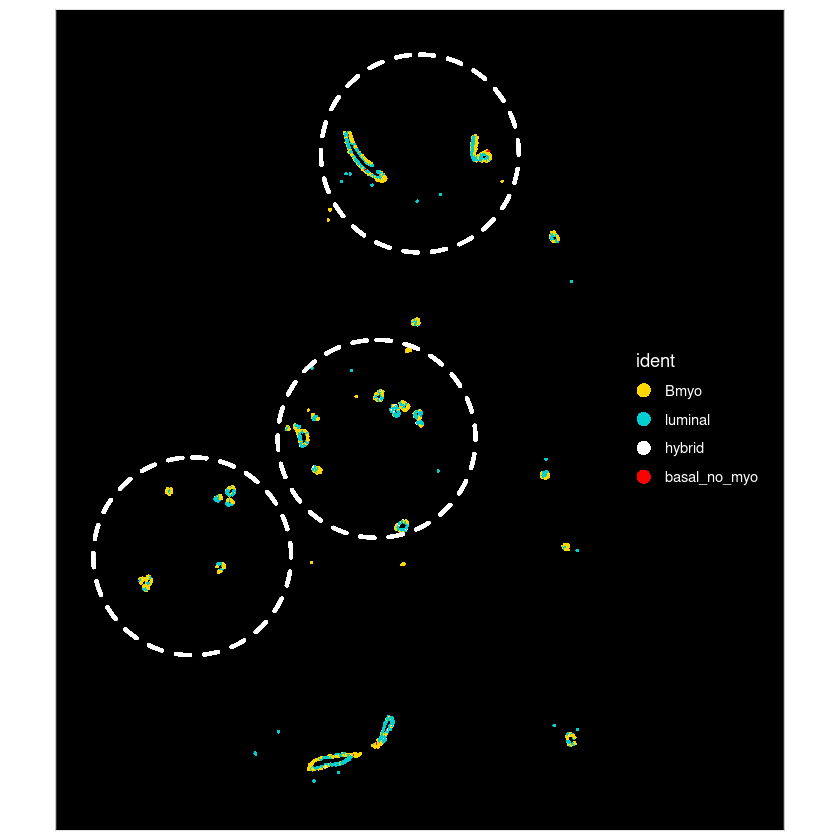

In [12]:
# Supplementary plot

Idents(codex.obj) <- "Cell.type.basal.hybrid"

p <- ImageDimPlot(codex.obj, cols=c("gold","darkturquoise","white","red"), size = 1)

# Overlay the exact mathematical circle
p + ggforce::geom_circle(
  aes(x0 = y0, y0 = x0, r = rad), 
  color = "white", 
  linetype = "dashed", 
  size = 1, 
  inherit.aes = FALSE
)+ ggforce::geom_circle(
  aes(x0 = y2, y0 = x2, r = rad), 
  color = "white", 
  linetype = "dashed", 
  size = 1, 
  inherit.aes = FALSE
)+ ggforce::geom_circle(
  aes(x0 = y3, y0 = x3, r = rad), 
  color = "white", 
  linetype = "dashed", 
  size = 1, 
  inherit.aes = FALSE
)